CSV files loaded
Predictions: [1064.869 1193.198 1201.218 ... 1209.239 1048.828 1161.115]
Actual: [ 974.32 1349.32 1068.07 ... 1259.2   993.83 1160.5 ]
R² Score: 0.127


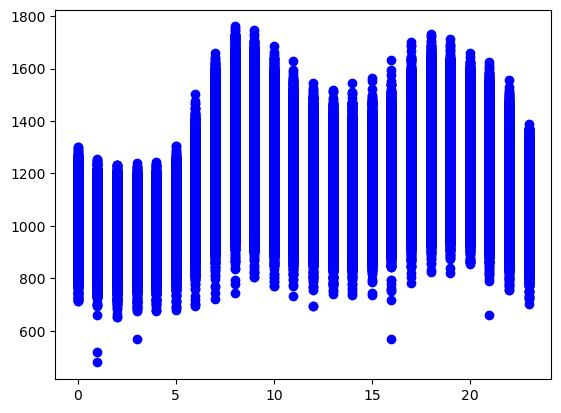

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# select demand for victoria and sort in order of date
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/TAS_clean.csv")
demand.sort()

df_list = [pd.read_csv(f) for f in demand]
if df_list:
    print("CSV files loaded")
else:
    print("No CSV files were loaded.")

df = pd.concat(df_list, ignore_index=True)

# Parse datetime column
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y/%m/%d %H:%M")

# Extract hour of the day
df['Hour'] = df['Datetime'].dt.hour

X = df['Hour'].values.reshape(-1, 1)
Y = np.array(df['Total Demand'].values)

# Flatten X for plotting
X_flat = X.flatten()


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)


# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
predictions = model.predict(X_test)
print("Predictions:", predictions.round(3))
print("Actual:", y_test.round(3))

r2 = model.score(X_test, y_test)
print("R² Score:", round(r2, 3))

# Plot original data
plt.scatter(X_flat, Y, color='blue', label='Data points')

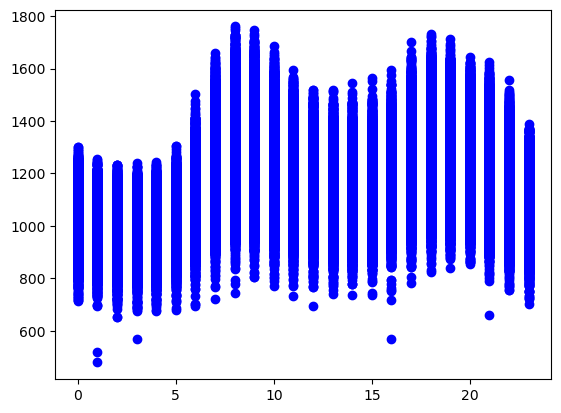

In [9]:
plt.scatter(X_train, y_train, color='blue', label='Data points')

CSV files loaded


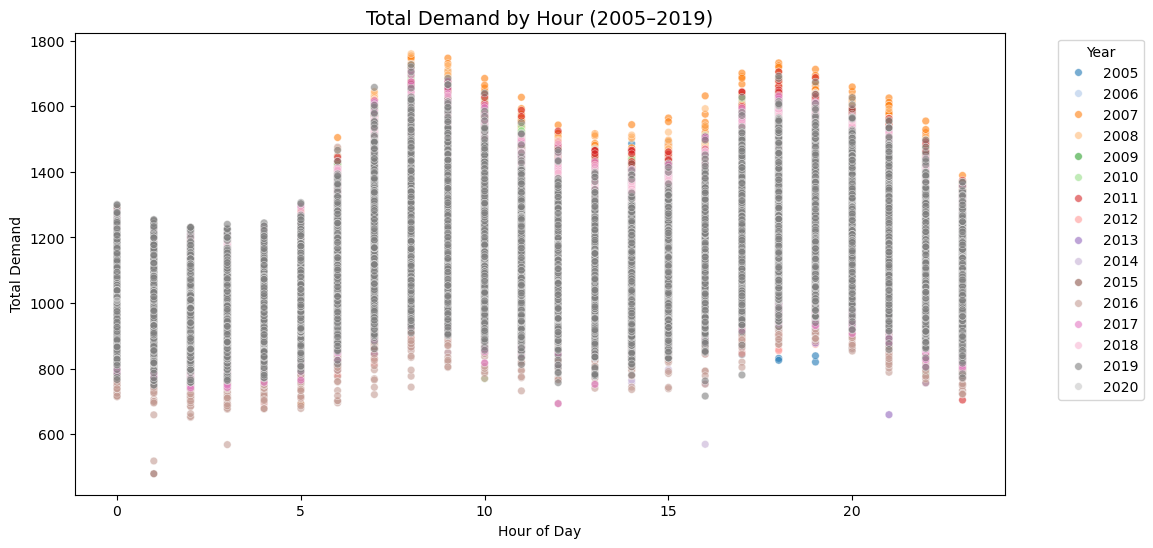

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# select demand for victoria and sort in order of date
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/TAS_clean.csv")
demand.sort()

df_list = [pd.read_csv(f) for f in demand]
if df_list:
    print("CSV files loaded")
else:
    print("No CSV files were loaded.")

df = pd.concat(df_list, ignore_index=True)

# Parse datetime column
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y/%m/%d %H:%M")

# Extract hour of the day
df['Hour'] = df['Datetime'].dt.hour

# Extract year column
df['Year'] = df['Datetime'].dt.year

# Scatter plot with color by year
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x="Hour",
    y="Total Demand",
    hue="Year",            # color by year
    palette="tab20",       # 20 distinct colors (good for many years)
    legend="full",
    s=30,                  # marker size
    alpha=0.6              # transparency
)

plt.title("Total Demand by Hour (2005–2019)", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Total Demand")
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside
plt.show()

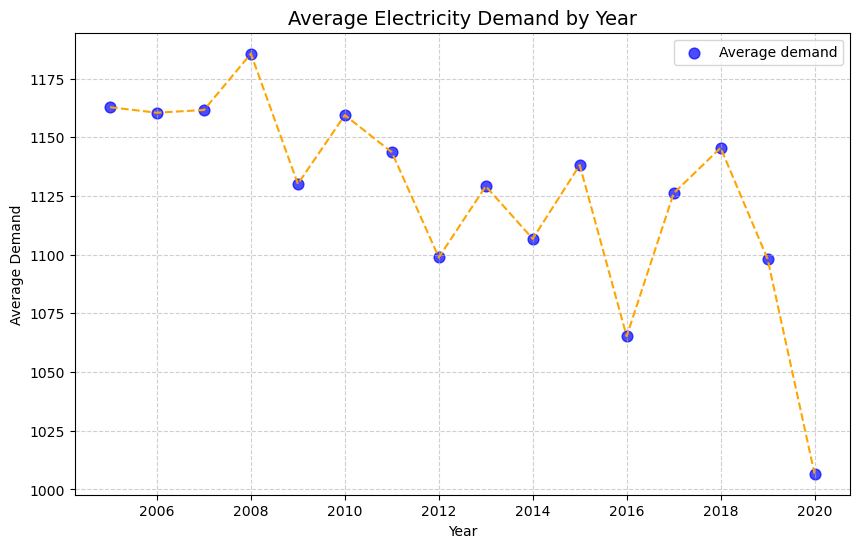

In [24]:
# Extract year column
df['Year'] = df['Datetime'].dt.year

# Compute average demand per year
avg_demand_year = df.groupby('Year')['Total Demand'].mean().reset_index()

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(
    avg_demand_year['Year'], 
    avg_demand_year['Total Demand'], 
    color='blue', 
    s=60, 
    alpha=0.7,
    label="Average demand"
)

plt.plot(avg_demand_year['Year'], avg_demand_year['Total Demand'], color='orange', linestyle='--')  # optional trend line

plt.title("Average Electricity Demand by Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average Demand")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()